In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
#import gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import random
import pdb
import plotly.express as px
import plotly.graph_objects as go
import pickle
import scipy.io
from matplotlib.font_manager import FontProperties
import pandas as pd
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from tqdm import tqdm
import matplotlib.animation as animation
import glob
from natsort import natsorted
from PIL import Image

def create_gif(pth, time_ind):
    #files = glob.glob(r"./imgs/*.png")
    files = glob.glob(os.path.join(pth,'*.png'))
    files = natsorted(files)
    image_array = []
    
    def update(i):
        im.set_array(image_array[i])
        return im, 
    
    for my_file in files:

        image = Image.open(my_file)
        image_array.append(image)
    
    # Create the figure and axes objects
    fig, ax = plt.subplots()

    # Set the initial image
    im = ax.imshow(image_array[0], animated=True)
    
    animation_fig = animation.FuncAnimation(fig, update, frames=len(image_array), interval=100, blit=True,repeat_delay=10,)

    # Show the animation
    #plt.show()

    #animation_fig.save("./imgs/animated_{}.gif".format(time_ind))
    animation_fig.save(os.path.join(pth,'animated_{}.gif').format(time_ind))
    pass

### Adding gamma_0 value for SINR computation ####

$\gamma = \frac{|h|_s^2P_t}{|h|_i^2P_t + N_0B}$

Assuming power transmitted power is same from all BSs then we have 

$\gamma = \frac{|h|_s^2}{|h|_i^2 + \frac{1}{\gamma_0}}$


where $\gamma_0 = P_t/N_0B$, you can assume P_t = 10 dBm, and the below calculations for $N_0$

In [2]:
## transmit power ###
Pt_dBm = 10  # Transmit power in dBm

#### Noise power ####
k = 1.38e-23  # Boltzmann's constant
T = 290       # Temperature in Kelvin
B = 10e6       # Bandwidth in Hz

# Calculate noise spectral density in Watts/Hz
Noise_spectral_density = k * T

# Convert noise spectral density to dBm/Hz
# Convert to Watts first then to dBm (1 mW = 0.001 W)
Noise_spectral_density_W = Noise_spectral_density * 1000  # Convert to mW
Noise_spectral_density_dBm = 10 * np.log10(Noise_spectral_density_W)
print('Noise_spectral_density_dBm', Noise_spectral_density_dBm)

# Calculate total noise power in Watts then convert to dBm
N_thermal = Noise_spectral_density * B  # Total noise power in Watts
N_thermal_dBm = 10 * np.log10(N_thermal * 1000)  # Convert noise power to dBm
print('thermal_noise_power(dBm)', N_thermal_dBm)

##### gamma_0 in dB ############
gamma_0_dB = Pt_dBm - N_thermal_dBm  # Calculate SNR in dB
#print('gamma_0 (dB)', gamma_0_dB)

##### gamma_0 ######
gamma_0 = np.power(10, gamma_0_dB/10)
print('1/gamma_0', 1/gamma_0)

Noise_spectral_density_dBm -173.97722915699805
thermal_noise_power(dBm) -103.97722915699808
1/gamma_0 4.001999999999999e-12


### 
CDF of SINR computed for F($\gamma$), for different channel realizations,
below is when the the device is at a mean distance of 1m from the serving BS with a standard deviation of 0.1 m, and mean distance from the interfering BS at 4 meters with std of 0.1m 

In [3]:
def return_cdf(a):
    sorted_a = np.sort(a)
    cdf = np.arange(1, len(sorted_a) + 1) / len(sorted_a)
    return sorted_a, cdf

In [4]:
############## Creating distances intra and inter ########
M = 5 # number of sub-networks 
Ts = 10000 # number of time slots
J = 3 # number of devices
f_c = 1.3 #GHz
N = 4
TxRxds = np.zeros((Ts, M, M*J))
d_intra = np.abs(np.random.normal(0.5,0.1,M*J))
d_intra = np.reshape(d_intra, (M,J))

In [5]:
def generate_random_point(grid_size):
    return np.random.uniform(0, grid_size, 2)

def generate_random_velocity():
    angle = np.random.uniform(0, 2 * np.pi)
    velocity = 11.11  # 40 km/h in m/s
    return np.array([velocity * np.cos(angle), velocity * np.sin(angle)])

def is_within_grid(point, grid_size):
    return all(0 <= coord <= grid_size for coord in point)

def handle_boundary_collisions(point, grid_size):
    angle = np.random.uniform(0, 2 * np.pi)
    velocity = 11.11
    if point[0] <= 0 or point[0] >= grid_size:
        angle = np.pi - angle if point[0] <= 0 else -angle
    if point[1] <= 0 or point[1] >= grid_size:
        angle = -np.pi / 2 - angle if point[1] <= 0 else np.pi / 2 - angle
    return np.array([velocity * np.cos(angle), velocity * np.sin(angle)])

def handle_ap_collisions(points, velocities, min_distance):
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            if np.linalg.norm(points[i] - points[j]) < min_distance:
                # Adjust direction randomly for both APs
                velocities[i] = generate_random_velocity()
                velocities[j] = generate_random_velocity()
    return velocities

def update_positions(points, velocities, tau, grid_size, min_distance):
    new_points = points + velocities * tau
    for i, point in enumerate(new_points):
        if not is_within_grid(point, grid_size):
            velocities[i] = handle_boundary_collisions(point, grid_size)
        new_points[i] = points[i] + velocities[i] * tau  # Recalculate with new velocity
    velocities = handle_ap_collisions(new_points, velocities, min_distance)
    return new_points, velocities

# Initialize parameters
grid_size = 20
num_points = M
min_distance = 2
tau = 0.01  # time interval in seconds

# Initialize points and velocities
points = np.array([generate_random_point(grid_size) for _ in range(num_points)])
velocities = np.array([generate_random_velocity() for _ in range(num_points)])
init_cents = points
# Simulation loop for 20 time steps
pth = r'C:\Users\sriniva3\OneDrive - Aalto University\Simulations\RL framework URLLC\RL framework_V2.0_DDPG\imgs'
#Ts = 1000
sub_net_cents = np.zeros((Ts+1, num_points, 2))
sub_net_cents[0] = init_cents
for step in tqdm(range(Ts-1)):
    points, velocities = update_positions(points, velocities, tau, grid_size, min_distance)
    sub_net_cents[step+1] = points
    '''
    # Plotting for visualization
    plt.figure(figsize=(3, 3))
    plt.scatter(points[:, 0], points[:, 1], c='red', label=f'Time Step {step+1}')
    plt.xlim(0, grid_size)
    plt.ylim(0, grid_size)
    plt.grid(True)
    plt.title(f'Access Points at Step {step+1}')
    plt.xlabel('Meters')
    plt.ylabel('Meters')
    #plt.legend()
    plt.savefig(os.path.join(pth, '{}.png'.format(step)))
    plt.close()
    #plt.show()
    ''';
#create_gif(pth, step)

100%|███████████████████████████████████████████████████████████████████████████| 9999/9999 [00:00<00:00, 15042.04it/s]


In [6]:
d_relative_locs = {}
for i in range(M):
    d_angle = np.random.uniform(0,2*np.pi,J) 
    d_r = np.random.uniform(0, 1, J)
    d_relative_locs[i] = np.vstack([d_r*np.cos(d_angle), d_r*np.sin(d_angle)])

In [7]:
def return_euclid_dist(device_x_coord, device_y_coord, AP_x_coord, AP_y_coord):
    device_coords = np.array([device_x_coord, device_y_coord])
    AP_coords = np.array([AP_x_coord, AP_y_coord])
    return np.linalg.norm(device_coords - AP_coords)

x_coords_ts, y_coords_ts = {}, {}
for ts in range(Ts):
    coords = sub_net_cents[ts]
    point_xs, point_ys = [], []
    for k in d_relative_locs.keys():
        point_x = d_relative_locs[k][0] + coords[k][0]
        point_y = d_relative_locs[k][1] + coords[k][1]
        #print(point_x, point_y)
        point_xs.append(point_x)
        point_ys.append(point_y)
    #break    
    x_coords_ts[ts] = point_xs
    y_coords_ts[ts] = point_ys

In [8]:
TxRxds = np.zeros((Ts, M, M*J))
for ts in range(Ts):
    device_x_coords, device_y_coords = np.array(x_coords_ts[ts]), np.array(y_coords_ts[ts])
    device_x_coords, device_y_coords = device_x_coords.flatten(), device_y_coords.flatten()
    AP_x_coords, AP_y_coords = sub_net_cents[ts][:,0], sub_net_cents[ts][:,1]
    
    #for dx in device_x_coords 
    dists = np.zeros((M,M*J))
    for i in range(AP_x_coords.shape[0]):
        dist = []
        for j in range(len(device_x_coords.flatten())):
            #dist = []
            #print(i,j)
            dist.append(return_euclid_dist(device_x_coords[j], device_y_coords[j], AP_x_coords[i], AP_y_coords[i]))
            #print(dist)
        dists[i] = np.array(dist)
    TxRxds[ts] = dists
    #break

#dist = return_euclid_dist(x_coords_ts[0], y_coords_ts[0], AP_x_coord, AP_y_coord)

(array([174481.,  76520., 104761., 115626., 100409.,  81527.,  56153.,
         27000.,  11079.,   2444.]),
 array([1.20969652e-03, 2.78738428e+00, 5.57355887e+00, 8.35973346e+00,
        1.11459080e+01, 1.39320826e+01, 1.67182572e+01, 1.95044318e+01,
        2.22906064e+01, 2.50767810e+01, 2.78629556e+01]),
 <BarContainer object of 10 artists>)

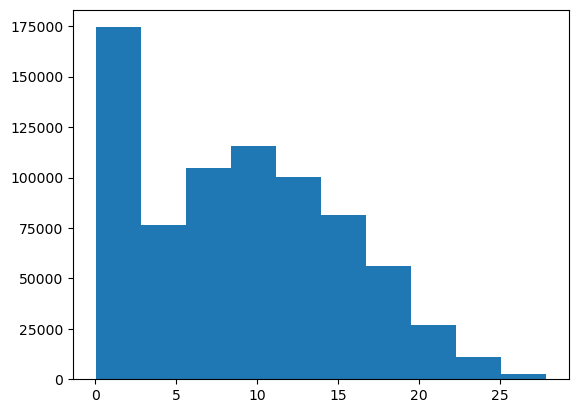

In [9]:
plt.hist(TxRxds.flatten())

In [10]:
TxRxds.shape

(10000, 5, 15)

### Using Jakes model 

In [11]:

def return_jakes_coeffcients(fd_max, TimeVaris, n_links = 5, plot = True):
    ff_gains, TimeSequences = [], []
    rays = 100
    for i in tqdm(range(n_links)):    
        #TimeVaris = np.arange(0,50,0.0005)
        #TimeVaris = np.arange(0,.2,0.005)
        frequs = np.sort(np.array([np.round(fd_max*np.cos(2*np.pi*np.random.uniform(0,1))) for _ in range(rays)]))
        phases = np.array([np.exp(1j*2*np.pi*np.random.uniform(0,1)) for _ in range(rays)])

        TimeSequence = []
        for t in TimeVaris:
            tab = np.exp(1j*2*np.pi*frequs*t)
            tabrot = tab*phases
            fun = np.sum(tabrot)
            TimeSequence.append(fun)
        TimeSequence = np.array(TimeSequence)

        #TimeSequence = TimeSequence/np.linalg.norm(TimeSequence)*np.sqrt(len(TimeSequence))
        PowerSequence1 =  np.abs(TimeSequence)**2;
        #plt.plot(TimeVaris[0:200], 10*np.log10(PowerSequence1)[0:200])
        ff_gains.append(PowerSequence1)
        TimeSequences.append(TimeSequence)
    ff_gains = np.array(ff_gains)/rays
    TimeSequences = np.array(TimeSequences)
    if plot:
        plt.plot(TimeVaris[0:200], 10*np.log10(ff_gains[0])[0:200])
        plt.show()
    return ff_gains, TimeSequences

v = 40 #kmph 
v_ms = v*5/18
c = 3*1e8
tau = .01
fd_max = v_ms*f_c*1e9/c
TimeVaris = np.arange(0,5,5/Ts)

ff_gains, TimeSequences = return_jakes_coeffcients(fd_max, TimeVaris, n_links = M*(M-1)*J*N, plot = False)
#plt.plot(TimeVaris[0:Ts], 10*np.log10(ff_gains.flatten()[0:Ts]))
#plt.show()

100%|████████████████████████████████████████████████████████████████████████████████| 240/240 [00:51<00:00,  4.68it/s]


In [12]:
#np.save( 'ff_gains_3000.npy',ff_gains)
#ff_gains = np.load('ff_gains_3000.npy')

In [13]:
############ fast fading coeffecients ########

K = 4  # Rician K-factor

# Compute LOS and NLOS scaling factors
LOS_scale = np.sqrt(K / (K + 1))  # LOS component scaling
NLOS_scale = np.sqrt(1 / (K + 1))  # NLOS component scaling
# Generate LOS component
random_phase = np.exp(1j * 2 * np.pi * np.random.rand(M, J, N))  # Same random phase for all elements
LOS_component = LOS_scale * np.ones((M, J, N)) * random_phase
# Generate NLOS component
NLOS_component = NLOS_scale * (np.random.normal(0, 1 / np.sqrt(2), (M, J, N)) +
                               1j * np.random.normal(0, 1 / np.sqrt(2), (M, J, N)))
# Combine LOS and NLOS components
FastFadingChannels = LOS_component + NLOS_component

#FastFadingChannels = np.random.normal(0,1/np.sqrt(2), M*J*N) + 1j*np.random.normal(0,1/np.sqrt(2), M*J*N)
FastFadingChannels = np.reshape(FastFadingChannels,(M,J,N))
FadingGains = np.abs(FastFadingChannels)**2
#all_SINRsdB, all_MeansPerSubNW, all_DiffsFromMean = np.zeros((Ts, M*J)), np.zeros((Ts, M)), np.zeros((Ts, M*J))
all_SINRsdB = np.zeros((Ts, M,J,N))
alltime_WantedSigPerDev, alltime_InterfPowsPerDev = [], []
for ts in range(Ts):
    

    #FadingGains.shape

    all_fast_fading_gains = np.zeros((M,M*J,N))
    for m in range(M):
        jakes_coeffs = ff_gains[:,ts]
        jakes_coeffs = np.reshape(jakes_coeffs,(M,(M-1)*J,N))
        all_fast_fading_gains[m] = np.concatenate([FadingGains[m], jakes_coeffs[m]])
    all_fast_fading_gains = np.array(all_fast_fading_gains)
    
    PL_los = 31.84 +21.5*np.log10(TxRxds[ts]) + 19*np.log10(f_c)
    PL = 33+25.5*np.log10(TxRxds[ts])+20*np.log10(f_c)
    PL_nlos = np.max((PL_los, PL), axis = 0)
    PathGains = np.power(10, -PL_nlos/10)
    PathGains = np.repeat(PathGains[:, :, np.newaxis], N, axis=2)

    ##### Compute total path gains ########
    #pdb.set_trace()
    PathGainsTot = PathGains*all_fast_fading_gains

    #### Compute WantedSigPerDev ######
    WantedSigPerDev = np.zeros((M,J,N))
    for m in range(M):
        WantedSigPerDev[m] = PathGainsTot[m,m*J:(m+1)*J]
    alltime_WantedSigPerDev.append(WantedSigPerDev)
    InterfPowsPerDev = np.zeros((M,J,N))
    for m in range(M):
        Interferers = [i for i in range(M) if i!=m]
        Devs = np.arange(m*J,(m+1)*J)
        #print(Interferers, Devs)
        InterfPowGains = PathGainsTot[np.ix_(Interferers, Devs)]
        InterfPowsPerDev[m,] = np.sum(InterfPowGains, axis = 0)
    alltime_InterfPowsPerDev.append(InterfPowsPerDev)
    SINRs = WantedSigPerDev/(InterfPowsPerDev + 1/gamma_0);
    SINRsdB = 10*np.log10(SINRs)
    all_SINRsdB[ts,:] = SINRsdB
alltime_WantedSigPerDev = np.array(alltime_WantedSigPerDev)
alltime_InterfPowsPerDev = np.array(alltime_InterfPowsPerDev)

In [14]:
WantedSigPerDev.shape

(5, 3, 4)

25.37508334072002


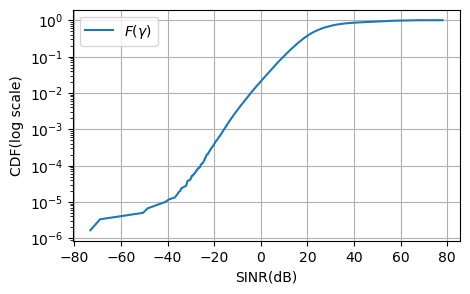

In [15]:
a1, cdf1 = return_cdf(all_SINRsdB.flatten())
plt.figure(figsize= [5,3])
#plt.ylim(np.min(cdf2))
plt.semilogy(a1, cdf1, label = r'$F(\gamma)$')
plt.grid()
plt.xlabel('SINR(dB)')
plt.ylabel('CDF(log scale)')
plt.legend()
print(np.mean(all_SINRsdB.flatten()))

In [16]:
PathGainsTot.shape

(5, 15, 4)

In [17]:
InterfPowGains.shape

(4, 3, 4)

19.352531324873304


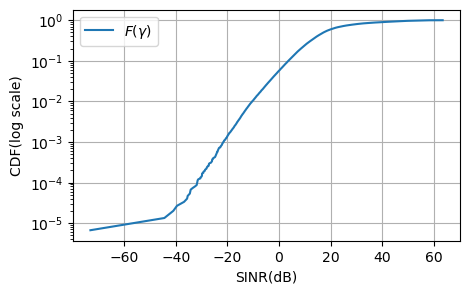

In [18]:
alltime_SINRsdB_combined = []
all_SINRslin = np.power(10, all_SINRsdB/10)
for ts in range(all_SINRsdB.shape[0]):
    vals = all_SINRslin[ts,:,:,:]
    SINRS_combined = np.min(vals, axis = 2)
    SINRsdB_combined = 10*np.log10(SINRS_combined)
    alltime_SINRsdB_combined.append(SINRsdB_combined)
alltime_SINRsdB_combined = np.array(alltime_SINRsdB_combined)

a1, cdf1 = return_cdf(alltime_SINRsdB_combined.flatten())
plt.figure(figsize= [5,3])
#plt.ylim(np.min(cdf2))
plt.semilogy(a1, cdf1, label = r'$F(\gamma)$')
plt.grid()
plt.xlabel('SINR(dB)')
plt.ylabel('CDF(log scale)')
plt.legend()
print(np.mean(alltime_SINRsdB_combined.flatten()))

In [19]:
all_SINRsdB.shape

(10000, 5, 3, 4)

### The below model needs to be integrated with DRL framework trained paralelly. 


##### prediction of SINR at t given 10 previous time slots #########
####### 10000 x 5x 5 x 30, 10000 is time slots, first 5 denotes the sub networks, 2nd 5 denotes the devices of a sub network, 
####### 30 denotes the channel resources. 


#### preparing data for a sub-network ########
######## each sub-network will have one LSTM layer getting trained in parallel with the main DRL agent ########
######### i.e., the LSTM layer is trained for a given example with a loss function and predicted SINR is given as the 
######### input to the DRL framework which is subsequently trained. This happens in an online fashion at every time-slot.

In [20]:
## data for a sub-network 
lag = 10
inp_data, out_data = [], []
for i in range(M):
    sinr_sub_nw = all_SINRsdB[:,0,:,:]
    data_per_device = sinr_sub_nw[:,0,:]
    for t in range(0, len(data_per_device)-lag):
        inp_data.append(data_per_device[t:t+lag])
        out_data.append(data_per_device[t+lag])

    
inp_data = np.array(inp_data)
out_data = np.array(out_data)

In [21]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Define the LSTM layer
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        
        # Define the output layer
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        # Initialize cell state with zeros
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

In [22]:
samp_no = int(0.95*len(inp_data))
inp_train_data = inp_data[0:samp_no]
out_train_data = out_data[0:samp_no]
inp_test_data = inp_data[samp_no:]
out_test_data = out_data[samp_no:]

# Convert numpy arrays to PyTorch tensors
inp_train_data = torch.tensor(inp_train_data, dtype=torch.float32)
out_train_data = torch.tensor(out_train_data, dtype=torch.float32)
inp_test_data = torch.tensor(inp_test_data, dtype=torch.float32)
out_test_data = torch.tensor(out_test_data, dtype=torch.float32)


inp_test_data 
# Create a dataset and dataloader
train_dataset = TensorDataset(inp_train_data, out_train_data)
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)


In [23]:
# Set device (CPU or GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model parameters
input_dim = N
hidden_dim = 128
output_dim = N
num_layers = 1
num_epochs = 50
learning_rate = 1e-3

# Initialize the model, loss function and optimizer
model = LSTMModel(input_dim, hidden_dim, output_dim, num_layers).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
epoch_loss = []
# Training loop
for epoch in range(num_epochs):
    for i, (inputs, targets) in enumerate(train_loader):
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss.append(loss.item())
        #if (i+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')


Epoch [1/50], Step [1/742], Loss: 503.4277
Epoch [1/50], Step [2/742], Loss: 485.1058
Epoch [1/50], Step [3/742], Loss: 423.4709
Epoch [1/50], Step [4/742], Loss: 484.4154
Epoch [1/50], Step [5/742], Loss: 420.1086
Epoch [1/50], Step [6/742], Loss: 473.2527
Epoch [1/50], Step [7/742], Loss: 470.9661
Epoch [1/50], Step [8/742], Loss: 486.1104
Epoch [1/50], Step [9/742], Loss: 488.7794
Epoch [1/50], Step [10/742], Loss: 452.8347
Epoch [1/50], Step [11/742], Loss: 427.5100
Epoch [1/50], Step [12/742], Loss: 431.1005
Epoch [1/50], Step [13/742], Loss: 419.2236
Epoch [1/50], Step [14/742], Loss: 403.4978
Epoch [1/50], Step [15/742], Loss: 373.5098
Epoch [1/50], Step [16/742], Loss: 400.1180
Epoch [1/50], Step [17/742], Loss: 413.4948
Epoch [1/50], Step [18/742], Loss: 414.7101
Epoch [1/50], Step [19/742], Loss: 383.0891
Epoch [1/50], Step [20/742], Loss: 421.5039
Epoch [1/50], Step [21/742], Loss: 380.9966
Epoch [1/50], Step [22/742], Loss: 385.7048
Epoch [1/50], Step [23/742], Loss: 373.20

Epoch [1/50], Step [189/742], Loss: 27.3061
Epoch [1/50], Step [190/742], Loss: 31.8901
Epoch [1/50], Step [191/742], Loss: 28.0145
Epoch [1/50], Step [192/742], Loss: 30.6156
Epoch [1/50], Step [193/742], Loss: 19.0018
Epoch [1/50], Step [194/742], Loss: 16.8028
Epoch [1/50], Step [195/742], Loss: 17.6580
Epoch [1/50], Step [196/742], Loss: 16.7048
Epoch [1/50], Step [197/742], Loss: 23.4679
Epoch [1/50], Step [198/742], Loss: 21.0972
Epoch [1/50], Step [199/742], Loss: 17.9101
Epoch [1/50], Step [200/742], Loss: 25.3870
Epoch [1/50], Step [201/742], Loss: 16.9323
Epoch [1/50], Step [202/742], Loss: 26.1936
Epoch [1/50], Step [203/742], Loss: 24.0377
Epoch [1/50], Step [204/742], Loss: 18.6650
Epoch [1/50], Step [205/742], Loss: 15.3304
Epoch [1/50], Step [206/742], Loss: 17.8954
Epoch [1/50], Step [207/742], Loss: 19.6705
Epoch [1/50], Step [208/742], Loss: 20.1346
Epoch [1/50], Step [209/742], Loss: 21.0940
Epoch [1/50], Step [210/742], Loss: 19.7688
Epoch [1/50], Step [211/742], Lo

Epoch [1/50], Step [378/742], Loss: 2.7982
Epoch [1/50], Step [379/742], Loss: 5.1044
Epoch [1/50], Step [380/742], Loss: 2.9929
Epoch [1/50], Step [381/742], Loss: 3.5207
Epoch [1/50], Step [382/742], Loss: 5.4933
Epoch [1/50], Step [383/742], Loss: 3.2842
Epoch [1/50], Step [384/742], Loss: 3.2137
Epoch [1/50], Step [385/742], Loss: 3.3424
Epoch [1/50], Step [386/742], Loss: 6.0157
Epoch [1/50], Step [387/742], Loss: 3.8347
Epoch [1/50], Step [388/742], Loss: 3.9691
Epoch [1/50], Step [389/742], Loss: 4.4340
Epoch [1/50], Step [390/742], Loss: 4.2752
Epoch [1/50], Step [391/742], Loss: 4.1991
Epoch [1/50], Step [392/742], Loss: 3.1591
Epoch [1/50], Step [393/742], Loss: 4.4559
Epoch [1/50], Step [394/742], Loss: 4.2197
Epoch [1/50], Step [395/742], Loss: 3.6787
Epoch [1/50], Step [396/742], Loss: 4.7575
Epoch [1/50], Step [397/742], Loss: 2.7726
Epoch [1/50], Step [398/742], Loss: 4.1849
Epoch [1/50], Step [399/742], Loss: 4.6570
Epoch [1/50], Step [400/742], Loss: 2.7971
Epoch [1/50

Epoch [1/50], Step [582/742], Loss: 1.1683
Epoch [1/50], Step [583/742], Loss: 1.7453
Epoch [1/50], Step [584/742], Loss: 1.2865
Epoch [1/50], Step [585/742], Loss: 1.1473
Epoch [1/50], Step [586/742], Loss: 1.0810
Epoch [1/50], Step [587/742], Loss: 1.7132
Epoch [1/50], Step [588/742], Loss: 1.4103
Epoch [1/50], Step [589/742], Loss: 1.1243
Epoch [1/50], Step [590/742], Loss: 0.9707
Epoch [1/50], Step [591/742], Loss: 1.3136
Epoch [1/50], Step [592/742], Loss: 2.1402
Epoch [1/50], Step [593/742], Loss: 1.3946
Epoch [1/50], Step [594/742], Loss: 1.2175
Epoch [1/50], Step [595/742], Loss: 1.4583
Epoch [1/50], Step [596/742], Loss: 1.3527
Epoch [1/50], Step [597/742], Loss: 1.2346
Epoch [1/50], Step [598/742], Loss: 1.1022
Epoch [1/50], Step [599/742], Loss: 1.0740
Epoch [1/50], Step [600/742], Loss: 1.1831
Epoch [1/50], Step [601/742], Loss: 1.6275
Epoch [1/50], Step [602/742], Loss: 0.9129
Epoch [1/50], Step [603/742], Loss: 1.6505
Epoch [1/50], Step [604/742], Loss: 2.0271
Epoch [1/50

Epoch [2/50], Step [44/742], Loss: 2.1888
Epoch [2/50], Step [45/742], Loss: 1.5932
Epoch [2/50], Step [46/742], Loss: 0.5158
Epoch [2/50], Step [47/742], Loss: 0.8715
Epoch [2/50], Step [48/742], Loss: 0.4073
Epoch [2/50], Step [49/742], Loss: 0.5106
Epoch [2/50], Step [50/742], Loss: 0.4808
Epoch [2/50], Step [51/742], Loss: 0.7947
Epoch [2/50], Step [52/742], Loss: 1.8450
Epoch [2/50], Step [53/742], Loss: 0.9536
Epoch [2/50], Step [54/742], Loss: 0.5032
Epoch [2/50], Step [55/742], Loss: 0.3109
Epoch [2/50], Step [56/742], Loss: 0.5439
Epoch [2/50], Step [57/742], Loss: 0.4232
Epoch [2/50], Step [58/742], Loss: 0.3445
Epoch [2/50], Step [59/742], Loss: 1.2016
Epoch [2/50], Step [60/742], Loss: 0.8698
Epoch [2/50], Step [61/742], Loss: 0.6571
Epoch [2/50], Step [62/742], Loss: 0.6696
Epoch [2/50], Step [63/742], Loss: 0.5384
Epoch [2/50], Step [64/742], Loss: 0.7240
Epoch [2/50], Step [65/742], Loss: 0.4167
Epoch [2/50], Step [66/742], Loss: 0.4039
Epoch [2/50], Step [67/742], Loss:

...

Epoch [49/50], Step [599/742], Loss: 0.0259
Epoch [49/50], Step [600/742], Loss: 0.0371
Epoch [49/50], Step [601/742], Loss: 0.0168
Epoch [49/50], Step [602/742], Loss: 0.0209
Epoch [49/50], Step [603/742], Loss: 0.0333
Epoch [49/50], Step [604/742], Loss: 0.0387
Epoch [49/50], Step [605/742], Loss: 0.0175
Epoch [49/50], Step [606/742], Loss: 0.0311
Epoch [49/50], Step [607/742], Loss: 0.0225
Epoch [49/50], Step [608/742], Loss: 0.0292
Epoch [49/50], Step [609/742], Loss: 0.0261
Epoch [49/50], Step [610/742], Loss: 0.0187
Epoch [49/50], Step [611/742], Loss: 0.0200
Epoch [49/50], Step [612/742], Loss: 0.0141
Epoch [49/50], Step [613/742], Loss: 0.0194
Epoch [49/50], Step [614/742], Loss: 0.0341
Epoch [49/50], Step [615/742], Loss: 0.0082
Epoch [49/50], Step [616/742], Loss: 0.0226
Epoch [49/50], Step [617/742], Loss: 0.0148
Epoch [49/50], Step [618/742], Loss: 0.0095
Epoch [49/50], Step [619/742], Loss: 0.0323
Epoch [49/50], Step [620/742], Loss: 0.0096
Epoch [49/50], Step [621/742], L

Epoch [50/50], Step [61/742], Loss: 0.0157
Epoch [50/50], Step [62/742], Loss: 0.0309
Epoch [50/50], Step [63/742], Loss: 0.0118
Epoch [50/50], Step [64/742], Loss: 0.0315
Epoch [50/50], Step [65/742], Loss: 0.0216
Epoch [50/50], Step [66/742], Loss: 0.0245
Epoch [50/50], Step [67/742], Loss: 0.0228
Epoch [50/50], Step [68/742], Loss: 0.0274
Epoch [50/50], Step [69/742], Loss: 0.0120
Epoch [50/50], Step [70/742], Loss: 0.0186
Epoch [50/50], Step [71/742], Loss: 0.0221
Epoch [50/50], Step [72/742], Loss: 0.0251
Epoch [50/50], Step [73/742], Loss: 0.0132
Epoch [50/50], Step [74/742], Loss: 0.0106
Epoch [50/50], Step [75/742], Loss: 0.0127
Epoch [50/50], Step [76/742], Loss: 0.0309
Epoch [50/50], Step [77/742], Loss: 0.0158
Epoch [50/50], Step [78/742], Loss: 0.0528
Epoch [50/50], Step [79/742], Loss: 0.0295
Epoch [50/50], Step [80/742], Loss: 0.0138
Epoch [50/50], Step [81/742], Loss: 0.0225
Epoch [50/50], Step [82/742], Loss: 0.0418
Epoch [50/50], Step [83/742], Loss: 0.0165
Epoch [50/5

Epoch [50/50], Step [255/742], Loss: 0.0226
Epoch [50/50], Step [256/742], Loss: 0.0103
Epoch [50/50], Step [257/742], Loss: 0.0128
Epoch [50/50], Step [258/742], Loss: 0.0304
Epoch [50/50], Step [259/742], Loss: 0.0107
Epoch [50/50], Step [260/742], Loss: 0.0133
Epoch [50/50], Step [261/742], Loss: 0.0161
Epoch [50/50], Step [262/742], Loss: 0.0231
Epoch [50/50], Step [263/742], Loss: 0.0198
Epoch [50/50], Step [264/742], Loss: 0.0496
Epoch [50/50], Step [265/742], Loss: 0.0158
Epoch [50/50], Step [266/742], Loss: 0.0258
Epoch [50/50], Step [267/742], Loss: 0.0227
Epoch [50/50], Step [268/742], Loss: 0.0149
Epoch [50/50], Step [269/742], Loss: 0.0140
Epoch [50/50], Step [270/742], Loss: 0.0155
Epoch [50/50], Step [271/742], Loss: 0.0079
Epoch [50/50], Step [272/742], Loss: 0.0085
Epoch [50/50], Step [273/742], Loss: 0.0100
Epoch [50/50], Step [274/742], Loss: 0.0144
Epoch [50/50], Step [275/742], Loss: 0.0181
Epoch [50/50], Step [276/742], Loss: 0.0254
Epoch [50/50], Step [277/742], L

Epoch [50/50], Step [443/742], Loss: 0.0292
Epoch [50/50], Step [444/742], Loss: 0.0175
Epoch [50/50], Step [445/742], Loss: 0.0179
Epoch [50/50], Step [446/742], Loss: 0.0096
Epoch [50/50], Step [447/742], Loss: 0.0174
Epoch [50/50], Step [448/742], Loss: 0.0314
Epoch [50/50], Step [449/742], Loss: 0.0522
Epoch [50/50], Step [450/742], Loss: 0.0118
Epoch [50/50], Step [451/742], Loss: 0.0491
Epoch [50/50], Step [452/742], Loss: 0.0299
Epoch [50/50], Step [453/742], Loss: 0.0228
Epoch [50/50], Step [454/742], Loss: 0.0431
Epoch [50/50], Step [455/742], Loss: 0.0146
Epoch [50/50], Step [456/742], Loss: 0.0273
Epoch [50/50], Step [457/742], Loss: 0.0116
Epoch [50/50], Step [458/742], Loss: 0.0199
Epoch [50/50], Step [459/742], Loss: 0.0541
Epoch [50/50], Step [460/742], Loss: 0.0223
Epoch [50/50], Step [461/742], Loss: 0.0162
Epoch [50/50], Step [462/742], Loss: 0.0478
Epoch [50/50], Step [463/742], Loss: 0.0099
Epoch [50/50], Step [464/742], Loss: 0.0253
Epoch [50/50], Step [465/742], L

Epoch [50/50], Step [638/742], Loss: 0.0466
Epoch [50/50], Step [639/742], Loss: 0.0269
Epoch [50/50], Step [640/742], Loss: 0.0197
Epoch [50/50], Step [641/742], Loss: 0.0464
Epoch [50/50], Step [642/742], Loss: 0.0297
Epoch [50/50], Step [643/742], Loss: 0.0185
Epoch [50/50], Step [644/742], Loss: 0.0348
Epoch [50/50], Step [645/742], Loss: 0.0232
Epoch [50/50], Step [646/742], Loss: 0.0626
Epoch [50/50], Step [647/742], Loss: 0.0218
Epoch [50/50], Step [648/742], Loss: 0.0119
Epoch [50/50], Step [649/742], Loss: 0.0469
Epoch [50/50], Step [650/742], Loss: 0.0222
Epoch [50/50], Step [651/742], Loss: 0.0449
Epoch [50/50], Step [652/742], Loss: 0.0270
Epoch [50/50], Step [653/742], Loss: 0.0250
Epoch [50/50], Step [654/742], Loss: 0.0115
Epoch [50/50], Step [655/742], Loss: 0.0281
Epoch [50/50], Step [656/742], Loss: 0.0408
Epoch [50/50], Step [657/742], Loss: 0.0230
Epoch [50/50], Step [658/742], Loss: 0.0383
Epoch [50/50], Step [659/742], Loss: 0.0546
Epoch [50/50], Step [660/742], L

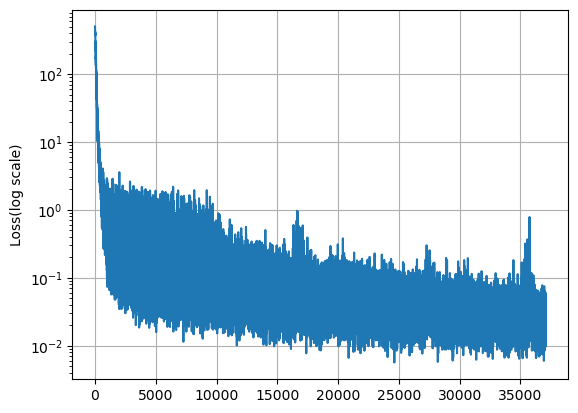

In [24]:
#plt.figure(1, figsize = [20,10])
plt.semilogy(epoch_loss)
plt.ylabel('Loss(log scale)')
plt.grid()

In [25]:
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    test_inputs = torch.tensor(inp_test_data, dtype=torch.float32).to(device)
    test_targets = torch.tensor(out_test_data, dtype=torch.float32).to(device)
    test_outputs = model(test_inputs)
    test_loss = criterion(test_outputs, test_targets)
    print(f'Test Loss: {test_loss.item():.4f}')

Test Loss: 0.0337


C:\Users\sriniva3\AppData\Local\Temp\ipykernel_26196\1681708791.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_inputs = torch.tensor(inp_test_data, dtype=torch.float32).to(device)
C:\Users\sriniva3\AppData\Local\Temp\ipykernel_26196\1681708791.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_targets = torch.tensor(out_test_data, dtype=torch.float32).to(device)


In [26]:
#torch.save(model, 'LSTM.pth')
torch.save(model.state_dict(), 'LSTM_state_dict.pth')


In [27]:
########## CDF plots ###########
pred = test_outputs.detach().numpy()
tgt = test_targets.detach().numpy()
error = tgt - pred
#pred = pred.flatten()
#tgt = tgt.flatten()
sortd_pred, a_pred = return_cdf(pred[:,0])
sortd_tgt, a_tgt = return_cdf(tgt[:,0])


In [28]:
#plt.plot(sortd_pred, a_pred)
#plt.plot(sortd_tgt, a_tgt, alpha = 0.3)

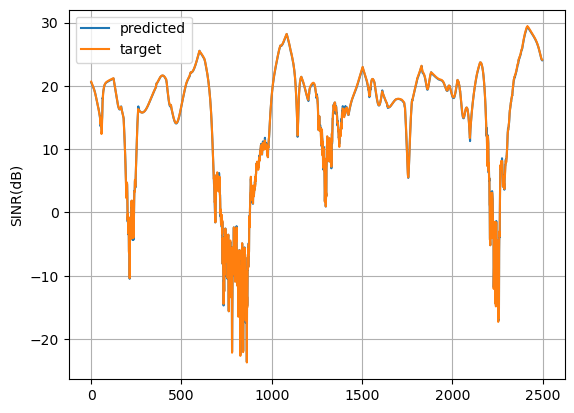

In [29]:
plt.plot(pred[:,0], alpha = 1, label = 'predicted')
plt.plot(tgt[:,0], label = 'target')
plt.legend()
plt.ylabel('SINR(dB)')
plt.grid()
plt.show()

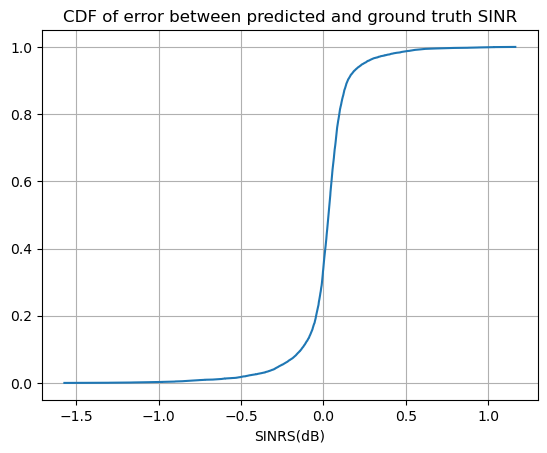

In [30]:
sortd_error, a_error = return_cdf(error.flatten())
plt.plot(sortd_error, a_error)
plt.title('CDF of error between predicted and ground truth SINR')
plt.xlabel('SINRS(dB)')
plt.grid()
plt.show()